# Tutorial 8: Single-Cell Foundation Model Embeddings
This notebook demonstrates how to extract **cell embeddings** from
state-of-the-art single-cell RNA-seq foundation models using `embpy`.

All models are accessed through the
[Helical](https://github.com/helicalAI/helical) package, providing
a unified interface over:

| Family | Models available | Reference |
|---|---|---|
| **scGPT** | 33M-cell transformer | [Cui et al. 2024](https://doi.org/10.1038/s41592-024-02201-0) |
| **Geneformer** | v1 (6L/12L), v2 (12L/18L/20L), cancer-tuned | [Theodoris et al. 2023](https://doi.org/10.1038/s41586-023-06139-9) |
| **UCE** | Cross-species (36M cells) | [Rosen et al. 2023](https://doi.org/10.1101/2023.11.28.568918) |
| **TranscriptFormer** | Metazoa / Exemplar / Sapiens (CZI) | [Fang et al. 2025](https://doi.org/10.1101/2025.04.25.650731) |
| **Tahoe-x1** | 70M / 1B / 3B | — |
| **Cell2Sentence-Scale** | 2B (Pythia) / 27B (Gemma-2) | — |

### What you'll learn

1. List and inspect available single-cell foundation models
2. Load a model and extract cell embeddings from an AnnData object
3. Compare embeddings across different models
4. Visualise cell embedding spaces with PCA and UMAP
5. Store embeddings in AnnData for downstream analysis

### Requirements

```bash
pip install embpy[helical]
```

In [ ]:
import logging
import os
import tempfile

logging.basicConfig(level=logging.INFO)

tmpdir = "/lustre/groups/ml01/workspace/goncalo.pinto/tmp"
os.makedirs(tmpdir, exist_ok=True)
os.environ["TMPDIR"] = tmpdir
tempfile.tempdir = tmpdir

## 1. Discover available models

`embpy` provides a registry of all supported single-cell foundation models.

In [2]:
from embpy.models.singlecell_models import (
    list_singlecell_models,
    singlecell_info,
    get_singlecell_wrapper,
)

models = list_singlecell_models()
print(f"Available single-cell models ({len(models)}):")
for m in models:
    card = singlecell_info(m)
    print(f"  {m:35s} — {card.description}")

KeyboardInterrupt: 

## 2. Load real data from sci-Plex

We load a random sample of **5,000 control cells** from the
sci-Plex 3 dataset (799K cells, 111K genes, 188 compounds across
A549/K562/MCF7 cell lines). This gives the models real gene
expression to work with.

In [3]:
import anndata as ad
import numpy as np
import pandas as pd

SCIPLEX_PATH = "/lustre/groups/ml01/workspace/goncalo.pinto/embpy/data/datasets/sciplex/srivatsan_2020_sciplex3.h5ad"
N_CELLS = 5_000

adata_full = ad.read_h5ad(SCIPLEX_PATH)
ctrl = adata_full[adata_full.obs["perturbation"] == "control"]

rng = np.random.default_rng(42)
idx = rng.choice(ctrl.n_obs, size=N_CELLS, replace=False)
adata = ctrl[idx].copy()

print(f"Loaded {adata.shape[0]:,} sci-Plex control cells x {adata.shape[1]:,} genes")
adata

Loaded 5,000 sci-Plex control cells x 110,983 genes


AnnData object with n_obs × n_vars = 5000 × 110983
    obs: 'ncounts', 'well', 'plate', 'cell_line', 'replicate', 'time', 'dose_value', 'pathway_level_1', 'pathway_level_2', 'perturbation', 'target', 'pathway', 'dose_unit', 'celltype', 'disease', 'cancer', 'tissue_type', 'organism', 'perturbation_type'
    var: 'ensembl_id'

In [4]:
print(adata.X)

  (np.int32(0), np.int32(8))	1
  (np.int32(0), np.int32(28))	1
  (np.int32(0), np.int32(92))	1
  (np.int32(0), np.int32(135))	1
  (np.int32(0), np.int32(161))	2
  (np.int32(0), np.int32(211))	1
  (np.int32(0), np.int32(229))	2
  (np.int32(0), np.int32(231))	1
  (np.int32(0), np.int32(244))	1
  (np.int32(0), np.int32(250))	1
  (np.int32(0), np.int32(268))	2
  (np.int32(0), np.int32(288))	1
  (np.int32(0), np.int32(292))	1
  (np.int32(0), np.int32(295))	1
  (np.int32(0), np.int32(300))	1
  (np.int32(0), np.int32(304))	1
  (np.int32(0), np.int32(324))	1
  (np.int32(0), np.int32(336))	1
  (np.int32(0), np.int32(378))	3
  (np.int32(0), np.int32(381))	1
  (np.int32(0), np.int32(390))	3
  (np.int32(0), np.int32(396))	1
  (np.int32(0), np.int32(401))	1
  (np.int32(0), np.int32(412))	1
  (np.int32(0), np.int32(425))	1
  :	:
  (np.int32(4999), np.int32(29539))	1
  (np.int32(4999), np.int32(30222))	1
  (np.int32(4999), np.int32(30355))	1
  (np.int32(4999), np.int32(30429))	1
  (np.int32(4999), np

## 3. Load a model and extract embeddings

The workflow is always three steps:

1. **Instantiate** a wrapper (via the factory or directly)
2. **Load** the model weights onto a device
3. **Embed** cells from an AnnData

### 3a. scGPT

In [5]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cuda


In [6]:
scgpt = get_singlecell_wrapper("scgpt", batch_size=10)
scgpt.load(device)

embs_scgpt = scgpt.embed_cells(adata)
print(f"scGPT embeddings: {embs_scgpt.shape}")
print(f"First cell (first 10 dims): {embs_scgpt[0, :10]}")

INFO:datasets:PyTorch version 2.7.0 available.
2026-05-04 09:29:52,663 - INFO:datasets:PyTorch version 2.7.0 available.
INFO:datasets:Polars version 1.40.0 available.
2026-05-04 09:29:52,702 - INFO:datasets:Polars version 1.40.0 available.
  warnings.warn(

2026-05-04 09:30:04,203 - WARNING:py.warnings:/ictstr01/groups/ml01/workspace/goncalo.pinto/embpy/.pixi/envs/helical-gpu/lib/python3.12/site-packages/helical/models/scgpt/model_dir/transformer.py:135: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer was not TransformerEncoderLayer
  warnings.warn(

INFO:helical.models.scgpt.model:Model finished initializing.
2026-05-04 09:30:06,548 - INFO:helical.models.scgpt.model:Model finished initializing.
INFO:helical.models.scgpt.model:'scGPT' model is in 'eval' mode, on device 'cuda' with embedding mode 'cell'.
2026-05-04 09:30:06,549 - INFO:helical.models.scgpt.model:'scGPT' model is in 'eval' mode, on device 'cuda' with embedding mode 'cel

scGPT embeddings: (5000, 512)
First cell (first 10 dims): [ 0.03291327  0.01790258  0.00508716  0.01068181  0.00175396 -0.00519093
 -0.00340226  0.02735573 -0.02072335  0.0532641 ]


### 3b. Geneformer

In [7]:
gf = get_singlecell_wrapper("geneformer_v2_12L", batch_size=10)
gf.load(device)

embs_gf = gf.embed_cells(adata)
print(f"Geneformer embeddings: {embs_gf.shape}")

`torch_dtype` is deprecated! Use `dtype` instead!
INFO:helical.models.geneformer.model:Model finished initializing.
2026-05-04 09:30:25,639 - INFO:helical.models.geneformer.model:Model finished initializing.
INFO:helical.models.geneformer.model:'gf-12L-38M-i4096' model is in 'eval' mode, on device 'cuda' with embedding mode 'cell'.
2026-05-04 09:30:25,640 - INFO:helical.models.geneformer.model:'gf-12L-38M-i4096' model is in 'eval' mode, on device 'cuda' with embedding mode 'cell'.
INFO:embpy.models.singlecell_models:Loaded Geneformer 'gf-12L-38M-i4096' on cuda
2026-05-04 09:30:25,641 - INFO:embpy.models.singlecell_models:Loaded Geneformer 'gf-12L-38M-i4096' on cuda
INFO:helical.models.geneformer.model:Processing data for Geneformer.
2026-05-04 09:30:25,642 - INFO:helical.models.geneformer.model:Processing data for Geneformer.
INFO:helical.utils.mapping:Mapped 35163 / 110983 genes to Ensembl IDs.
2026-05-04 09:30:25,997 - INFO:helical.utils.mapping:Mapped 35163 / 110983 genes to Ensembl

  0%|          | 0/500 [00:00<?, ?it/s]

INFO:helical.models.geneformer.model:Finished getting embeddings.
2026-05-04 09:31:08,449 - INFO:helical.models.geneformer.model:Finished getting embeddings.


Geneformer embeddings: (5000, 512)


### 3c. UCE

In [ ]:
uce = get_singlecell_wrapper("uce", batch_size=10)
uce.load(device)

embs_uce = uce.embed_cells(adata)
print(f"UCE embeddings: {embs_uce.shape}")

INFO:helical.models.uce.model:Model finished initializing.
2026-05-04 09:31:18,461 - INFO:helical.models.uce.model:Model finished initializing.
INFO:helical.models.uce.model:'4layer_model' model is in 'eval' mode, on device 'cuda'.
2026-05-04 09:31:18,462 - INFO:helical.models.uce.model:'4layer_model' model is in 'eval' mode, on device 'cuda'.
INFO:embpy.models.singlecell_models:Loaded UCE on cuda
2026-05-04 09:31:18,464 - INFO:embpy.models.singlecell_models:Loaded UCE on cuda
INFO:helical.models.uce.model:Processing data for UCE.
2026-05-04 09:31:18,465 - INFO:helical.models.uce.model:Processing data for UCE.
INFO:helical.models.uce.gene_embeddings:Finished loading gene embeddings for 'human' from /home/icb/goncalo.pinto/.cache/helical/models/uce/protein_embeddings for model 'ESM2'.
2026-05-04 09:31:21,683 - INFO:helical.models.uce.gene_embeddings:Finished loading gene embeddings for 'human' from /home/icb/goncalo.pinto/.cache/helical/models/uce/protein_embeddings for model 'ESM2'.
IN

UCE embeddings: (5000, 1280)


### 3d. TranscriptFormer (CZI)

In [ ]:
tf = get_singlecell_wrapper("transcriptformer_sapiens", batch_size=10)
tf.load(device)

embs_tf = tf.embed_cells(adata)
print(f"TranscriptFormer-Sapiens embeddings: {embs_tf.shape}")

INFO:helical.models.transcriptformer.model:Loading cache config for tf_sapiens
2026-05-04 09:33:43,638 - INFO:helical.models.transcriptformer.model:Loading cache config for tf_sapiens
INFO:helical.models.transcriptformer.model:Merged cache config with user config for tf_sapiens
2026-05-04 09:33:43,644 - INFO:helical.models.transcriptformer.model:Merged cache config with user config for tf_sapiens
INFO:root:Loading vocabulary file: /home/icb/goncalo.pinto/.cache/helical/models/transcriptformer/tf_sapiens/vocabs/assay
2026-05-04 09:33:43,648 - INFO:root:Loading vocabulary file: /home/icb/goncalo.pinto/.cache/helical/models/transcriptformer/tf_sapiens/vocabs/assay
INFO:root:Loading ESM2 mappings from /home/icb/goncalo.pinto/.cache/helical/models/transcriptformer/tf_sapiens/vocabs
2026-05-04 09:33:43,649 - INFO:root:Loading ESM2 mappings from /home/icb/goncalo.pinto/.cache/helical/models/transcriptformer/tf_sapiens/vocabs
INFO:root:Building gene vocabulary
2026-05-04 09:33:56,655 - INFO:ro

23830


INFO:root:Gene mapping: 18860 / 110983 in vocab | not in vocab: 92123 | in vocab but zero expression: 2908 | in vocab and expressed: 15952
2026-05-04 09:34:11,294 - INFO:root:Gene mapping: 18860 / 110983 in vocab | not in vocab: 92123 | in vocab but zero expression: 2908 | in vocab and expressed: 15952
Embedding Cells: 100%|██████████| 500/500 [02:54<00:00,  2.87batch/s]
INFO:helical.models.transcriptformer.model:Combining predictions
2026-05-04 09:37:09,392 - INFO:helical.models.transcriptformer.model:Combining predictions
INFO:helical.models.transcriptformer.model:Returning 'cell_embeddings' from output.
2026-05-04 09:37:09,492 - INFO:helical.models.transcriptformer.model:Returning 'cell_embeddings' from output.


TranscriptFormer-Sapiens embeddings: (5000, 2048)


## 4. Compare embedding spaces

We can compare how different models organise cells by projecting each
high-dimensional embedding into a 2-D UMAP. `embpy.pl.all_embeddings`
wraps `embpy.tl.compute_umap` (scanpy `pp.neighbors` + `tl.umap` under
the hood) so the full neighbour-graph-plus-layout pipeline stays inside
the package -- no sklearn or standalone umap-learn calls required.

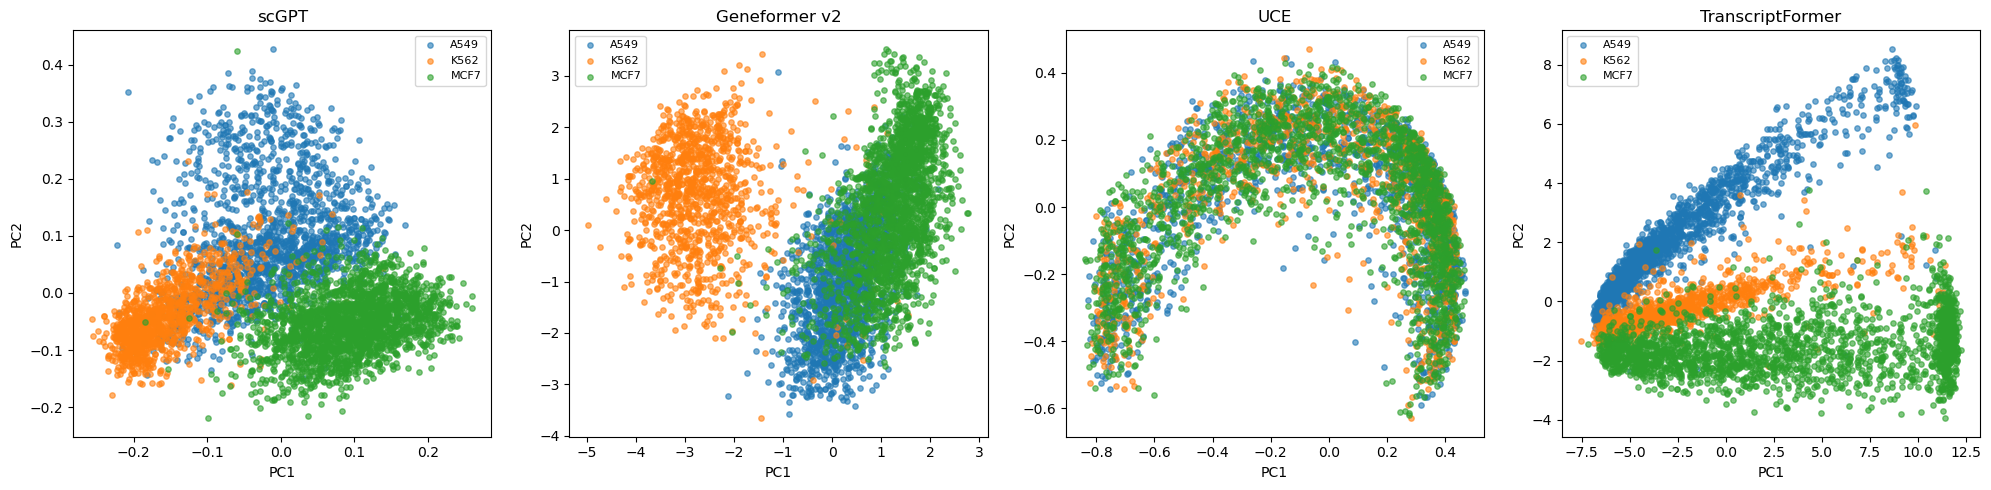

In [ ]:
import embpy.pl as epl

# Park each model's embeddings in .obsm so the embpy plotting utilities
# can address them by key (and reuse them in the next cells).
adata.obsm["X_scgpt"] = embs_scgpt
adata.obsm["X_geneformer"] = embs_gf
adata.obsm["X_uce"] = embs_uce
adata.obsm["X_transcriptformer"] = embs_tf

# `all_embeddings` computes a UMAP per embedding key (via embpy.tl.compute_umap,
# which wraps scanpy's pp.neighbors + tl.umap) and draws a grid of 2-D scatters
# colored by `color`. The UMAP coordinates are cached in .obsm[f"X_umap_{key}"],
# so re-running this cell is cheap.
fig = epl.all_embeddings(
    adata,
    obsm_keys=["X_scgpt", "X_geneformer", "X_uce", "X_transcriptformer"],
    method="umap",
    color="cell_line",
    ncols=4,
    figsize_per_panel=(5, 4),
)
fig.show()

## 5. Store embeddings in AnnData

It's convenient to store embeddings in `adata.obsm` for downstream analyses.

In [ ]:
# The foundation-model embeddings were stored in `.obsm` in section 4
# (so `all_embeddings` could address them by key). The UMAP plot step also
# cached per-embedding coordinates in `X_umap_<key>` -- both are already
# part of the AnnData and ready for downstream scanpy/scvi workflows.
print("Stored embedding keys:", list(adata.obsm.keys()))
adata

Stored embedding keys: ['X_scgpt', 'X_geneformer', 'X_uce', 'X_transcriptformer']


AnnData object with n_obs × n_vars = 5000 × 110983
    obs: 'ncounts', 'well', 'plate', 'cell_line', 'replicate', 'time', 'dose_value', 'pathway_level_1', 'pathway_level_2', 'perturbation', 'target', 'pathway', 'dose_unit', 'celltype', 'disease', 'cancer', 'tissue_type', 'organism', 'perturbation_type', 'total_counts', 'assay'
    var: 'ensembl_id', 'index', 'id_in_vocab', 'ensembl_id_collapsed'
    obsm: 'X_scgpt', 'X_geneformer', 'X_uce', 'X_transcriptformer'

## 6. Using the wrapper classes directly

Instead of the factory, you can instantiate wrappers directly for
more control over configuration.

In [ ]:
from embpy.models.singlecell_models import ScGPTWrapper, GeneformerWrapper

wrapper = ScGPTWrapper(batch_size=16)
wrapper.load(device)
print(f"Loaded: {wrapper}")
print(f"Embedding dim: {wrapper.embedding_dim}")

INFO:helical.models.scgpt.model:Model finished initializing.
2026-05-04 09:37:20,415 - INFO:helical.models.scgpt.model:Model finished initializing.
INFO:helical.models.scgpt.model:'scGPT' model is in 'eval' mode, on device 'cuda' with embedding mode 'cell'.
2026-05-04 09:37:20,416 - INFO:helical.models.scgpt.model:'scGPT' model is in 'eval' mode, on device 'cuda' with embedding mode 'cell'.
INFO:embpy.models.singlecell_models:Loaded scGPT on cuda
2026-05-04 09:37:20,418 - INFO:embpy.models.singlecell_models:Loaded scGPT on cuda


Loaded: ScGPTWrapper(model_name='ScGPTWrapper', device='cuda')
Embedding dim: 512


## 7. Larger models: Tahoe-x1 and Cell2Sentence-Scale

These models are substantially larger than the transformer-era
foundation models above. In particular, **Cell2Sentence-Scale 2B**
is a full Gemma-2 LLM (~5 GB of weights in bf16, plus large
activation buffers) and the 27B variant needs multi-GPU.

If your notebook has already loaded several of the smaller models,
their weights are still resident on the GPU -- so before loading
Cell2Sentence we explicitly free them and subsample `adata` to a
size that comfortably fits on a single 20-40 GB GPU.


In [ ]:
# Tahoe-x1 (70M — smallest variant)
tahoe = get_singlecell_wrapper("tahoe_70m", batch_size=10)
tahoe.load(device)

embs_tahoe = tahoe.embed_cells(adata)
print(f"Tahoe-x1 70M embeddings: {embs_tahoe.shape}")

INFO:helical.models.tahoe.model:Loading Tahoe model (size: 70m) from Hugging Face...
2026-05-04 09:37:34,187 - INFO:helical.models.tahoe.model:Loading Tahoe model (size: 70m) from Hugging Face...
INFO:helical.models.tahoe.tahoe_x1.model.model:MosaicML recommends using config.init_device="meta" with Composer + FSDP for faster initialization.
2026-05-04 09:37:35,779 - INFO:helical.models.tahoe.tahoe_x1.model.model:MosaicML recommends using config.init_device="meta" with Composer + FSDP for faster initialization.
INFO:helical.models.tahoe.model:Model loaded with 12 transformer layers.
2026-05-04 09:37:41,810 - INFO:helical.models.tahoe.model:Model loaded with 12 transformer layers.
INFO:helical.models.tahoe.model:Tahoe model is in 'eval' mode, on device 'cuda' with embedding mode 'cell' and attention implementation 'torch'.
2026-05-04 09:37:41,812 - INFO:helical.models.tahoe.model:Tahoe model is in 'eval' mode, on device 'cuda' with embedding mode 'cell' and attention implementation 'torc

Embedding cells:   0%|          | 0/500 [00:00<?, ?it/s]

INFO:helical.models.tahoe.model:Finished extracting embeddings. Cell shape: (5000, 512)
2026-05-04 09:38:33,942 - INFO:helical.models.tahoe.model:Finished extracting embeddings. Cell shape: (5000, 512)


Tahoe-x1 70M embeddings: (5000, 512)


In [ ]:
import gc, os

# Reduce allocator fragmentation. For full effect this must be set
# BEFORE `import torch`; we set it here defensively so re-runs benefit.
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

# Free every wrapper loaded earlier in this kernel. Each wrapper holds
# a `._model` reference to a large torch module whose parameters live
# on the GPU; dropping the wrapper is not enough -- we also clear the
# allocator's reserved blocks.
for _name in ("scgpt", "gf", "uce", "tf", "tahoe", "wrapper"):
    globals().pop(_name, None)
gc.collect()
torch.cuda.empty_cache()
torch.cuda.ipc_collect()
torch.cuda.synchronize()
free_gb, total_gb = (x / 1024**3 for x in torch.cuda.mem_get_info())
print(f"Free GPU memory before loading C2S: {free_gb:.2f} / {total_gb:.2f} GiB")

# Subsample to keep activations within a single 20-40 GB GPU. Cell2Sentence
# tokenizes cells into gene-rank sentences of up to ~9k tokens each,
# so even a batch size of 1 is memory-heavy.
N_C2S = 200
adata_small = adata[:N_C2S].copy()

c2s = get_singlecell_wrapper("cell2sentence_2b", batch_size=1)
c2s.load(device)

embs_c2s = c2s.embed_cells(adata_small)
print(f"Cell2Sentence-Scale 2B embeddings: {embs_c2s.shape}  (on {N_C2S} cells)")


Free GPU memory before loading C2S: 78.49 / 79.25 GiB


INFO:helical.models.c2s.model:Using SDPA for attention implementation - default for CPU
2026-05-04 09:38:34,742 - INFO:helical.models.c2s.model:Using SDPA for attention implementation - default for CPU
`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

INFO:helical.models.c2s.model:Successfully loaded model
2026-05-04 09:38:46,308 - INFO:helical.models.c2s.model:Successfully loaded model
INFO:embpy.models.singlecell_models:Loaded Cell2Sentence-Scale '2B' on cuda
2026-05-04 09:38:46,309 - INFO:embpy.models.singlecell_models:Loaded Cell2Sentence-Scale '2B' on cuda
INFO:helical.models.c2s.model:Processing data
2026-05-04 09:38:46,309 - INFO:helical.models.c2s.model:Processing data
Processing cells: 100%|██████████| 200/200 [00:00<00:00, 3246.62it/s]
INFO:helical.models.c2s.model:Successfully processed data
2026-05-04 09:39:04,321 - INFO:helical.models.c2s.model:Successfully processed data
INFO:helical.models.c2s.model:Extracting embeddings from dataset
2026-05-04 09:39:04,322 - INFO:helical.models.c2s.model:Extracting embeddings from dataset
Processing embeddings:  78%|███████▊  | 156/200 [00:44<00:10,  4.01it/s]Processing embeddings:  98%|█████████▊| 196/200 [00:54<00:00,  6.46it/s]

## 8. Cross-model agreement on the same cells

A single cell-vs-cell cosine matrix for one model is hard to interpret in
isolation. The sharper question is: **do different foundation models
agree on which cells are similar to which?** Because each model lives
in its own embedding space (scGPT is 512-D, Geneformer is 512-D, UCE is
1280-D, TranscriptFormer is 128-D), we cannot cosine cells across
models directly. Instead we compare their *relational* structure:

1. Compute the cell-vs-cell cosine matrix in each model's space.
2. Compare those matrices pairwise (Pearson correlation of the
   upper triangles; equivalent to representational similarity analysis).

High agreement means the models place the same cells near each other
even though their raw embedding coordinates are incomparable.

`embpy.pl.cross_model_similarity` does exactly this, with three
interchangeable agreement metrics:

- `method="cosine_correlation"` -- Pearson r between the cosine matrices (RSA-style).
- `method="knn"` -- mean Jaccard overlap of k-nearest-neighbour sets per cell.
- `method="ari"` -- Adjusted Rand Index between Leiden clusterings.

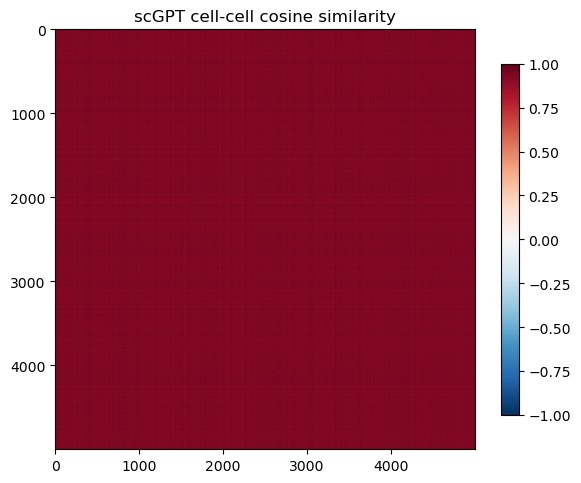

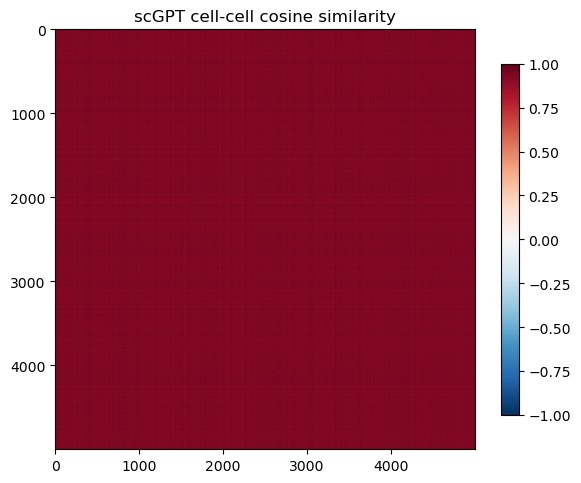

In [ ]:
# RSA-style agreement: how correlated are the cell-vs-cell cosine matrices
# of the four models? Values near +1 mean two models rank cell-cell
# similarities nearly identically; near 0 means they disagree.
fig_rsa = epl.cross_model_similarity(
    adata,
    obsm_keys=["X_scgpt", "X_geneformer", "X_uce", "X_transcriptformer"],
    labels=["scGPT", "Geneformer v2", "UCE", "TranscriptFormer"],
    method="cosine_correlation",
    figsize=(6, 5),
)
fig_rsa.show()

# Local-neighbourhood agreement: for each cell, how much do the
# k-nearest-neighbour sets overlap between models (mean Jaccard, k=20)?
# This is a stricter, cell-resolution view of the same question.
fig_knn = epl.cross_model_similarity(
    adata,
    obsm_keys=["X_scgpt", "X_geneformer", "X_uce", "X_transcriptformer"],
    labels=["scGPT", "Geneformer v2", "UCE", "TranscriptFormer"],
    method="knn",
    k=20,
    figsize=(6, 5),
)
fig_knn.show()

## 9. Preprocessing Pipelines

`embpy` provides two preprocessing pipelines via `preprocess_counts()`:

- **`"standard"`** -- filter, normalize, log1p, HVG selection.
  Stores raw counts in `.layers["counts"]` and processed data in
  `.layers["log_normalized"]`, while `.X` is restored to raw.
- **`"raw"`** -- QC filtering only, raw counts in `.X`.

In [ ]:
from embpy.pp.singlecell import preprocess_counts

adata_processed = preprocess_counts(
    adata, pipeline="standard", n_top_genes=2000,
)

print("Layers:", list(adata_processed.layers.keys()))
print(f".X shape (raw counts): {adata_processed.X.shape}")
print(f".layers['counts'] shape: {adata_processed.layers['counts'].shape}")
print(f".layers['log_normalized'] shape: {adata_processed.layers['log_normalized'].shape}")
if "highly_variable" in adata_processed.var.columns:
    n_hvg = adata_processed.var["highly_variable"].sum()
    print(f"HVGs marked: {n_hvg}")

INFO:embpy.pp.singlecell.preprocessing:After QC: 4998 cells x 23166 genes
2026-05-04 09:40:07,348 - INFO:embpy.pp.singlecell.preprocessing:After QC: 4998 cells x 23166 genes


## 10. PCA and scVI Embeddings

Beyond foundation models, `embpy` supports classical PCA and scVI
(variational autoencoder) as cell embedding methods. These are available
through the same `embed_cells()` interface.

In [ ]:
from embpy.embedder import BioEmbedder

embedder = BioEmbedder(device="auto")

# PCA embedding (50 components on log-normalized HVGs)
result_pca = embedder.embed_cells(
    adata, models=["pca"],
    preprocessing="standard",
    n_pca_components=50,
    n_top_genes=2000,
)
print(f"PCA embedding: {result_pca.obsm['X_pca'].shape}")
print(f"Layers: {list(result_pca.layers.keys())}")

INFO:root:CUDA device found, using GPU.
2026-05-04 08:45:22,005 - INFO:root:CUDA device found, using GPU.
INFO:root:GeneResolver initialized for human (Release 109).
2026-05-04 08:45:22,006 - INFO:root:GeneResolver initialized for human (Release 109).
INFO:root:Checking if Ensembl data needs downloading/indexing...
2026-05-04 08:45:25,519 - INFO:root:Checking if Ensembl data needs downloading/indexing...
INFO:pyensembl.sequence_data:Loaded sequence dictionary from /home/icb/goncalo.pinto/.cache/pyensembl/GRCh38/ensembl109/Homo_sapiens.GRCh38.cdna.all.fa.gz.pickle
2026-05-04 08:45:25,940 - INFO:pyensembl.sequence_data:Loaded sequence dictionary from /home/icb/goncalo.pinto/.cache/pyensembl/GRCh38/ensembl109/Homo_sapiens.GRCh38.cdna.all.fa.gz.pickle
INFO:pyensembl.sequence_data:Loaded sequence dictionary from /home/icb/goncalo.pinto/.cache/pyensembl/GRCh38/ensembl109/Homo_sapiens.GRCh38.ncrna.fa.gz.pickle
2026-05-04 08:45:26,102 - INFO:pyensembl.sequence_data:Loaded sequence dictionary f

PCA embedding: (4998, 50)
Layers: ['counts', 'log_normalized']


PCA embedding: (4998, 50)
Layers: ['counts', 'log_normalized']


In [ ]:
# scVI latent space (requires scvi-tools: `pip install scvi-tools` or
# `pixi add --feature helical scvi-tools`).
#
# `embed_cells` is resilient to missing model backends: if a model fails
# to load (e.g. `scvi-tools` not installed) it logs an error and returns
# the AnnData without that embedding in `.obsm`. So we check by key
# rather than catching ImportError.
result_scvi = embedder.embed_cells(
    adata, models=["scvi"],
    preprocessing="standard",
    n_latent=30,
    max_epochs=50,
    n_top_genes=2000,
)

if "X_scvi" in result_scvi.obsm:
    print(f"scVI embedding: {result_scvi.obsm['X_scvi'].shape}")
else:
    print(
        "scVI embedding not produced -- scvi-tools is likely not installed "
        "in this pixi env. See the log line above for the exact error."
    )


INFO:embpy.pp.singlecell.preprocessing:After QC: 4998 cells x 23166 genes
2026-05-04 09:40:25,333 - INFO:embpy.pp.singlecell.preprocessing:After QC: 4998 cells x 23166 genes
INFO:embpy.pp.singlecell.preprocessing:Identified 2000 highly variable genes
2026-05-04 09:40:25,508 - INFO:embpy.pp.singlecell.preprocessing:Identified 2000 highly variable genes
INFO:embpy.pp.singlecell.preprocessing:Pipeline 'standard' (backend=cpu): 4998 cells x 23166 genes, log_normalized in .layers, raw counts in .X
2026-05-04 09:40:25,518 - INFO:embpy.pp.singlecell.preprocessing:Pipeline 'standard' (backend=cpu): 4998 cells x 23166 genes, log_normalized in .layers, raw counts in .X
INFO:root:Embedding cells with 'scvi' ...
2026-05-04 09:40:25,519 - INFO:root:Embedding cells with 'scvi' ...
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
2026-05-04 09:40:48,157 - INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda)

Training:   0%|          | 0/50 [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=50` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=50` reached.
2026-05-04 09:41:10,735 - INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=50` reached.
INFO:embpy.models.singlecell_models:SCVI: trained 50 epochs, latent shape (4998, 30)
2026-05-04 09:41:10,873 - INFO:embpy.models.singlecell_models:SCVI: trained 50 epochs, latent shape (4998, 30)
INFO:root:  -> stored in .obsm['X_scvi'], shape (4998, 30)
2026-05-04 09:41:10,874 - INFO:root:  -> stored in .obsm['X_scvi'], shape (4998, 30)
INFO:root:embed_cells complete: 1 models, 4998 cells
2026-05-04 09:41:10,875 - INFO:root:embed_cells complete: 1 models, 4998 cells


scVI embedding: (4998, 30)


## 11. Multi-Model Embedding in One Call

Pass multiple model keys to `embed_cells()` to compute all embeddings
at once. Each is stored under its own `.obsm` key.

In [ ]:
result = embedder.embed_cells(
    adata,
    models=["pca", "scgpt"],
    preprocessing="standard",
    n_pca_components=50,
    n_top_genes=2000,
    batch_size=10,
)

print("Embedding keys in .obsm:")
for key in sorted(result.obsm.keys()):
    print(f"  {key}: shape {result.obsm[key].shape}")

print(f"\n.X (raw counts): {result.X.shape}")
print(f"Layers: {list(result.layers.keys())}")
print(f"Metadata: {list(result.uns.get('embpy_cell_embeddings', {}).keys())}")

INFO:embpy.pp.singlecell.preprocessing:After QC: 4998 cells x 23166 genes
2026-05-04 09:41:11,218 - INFO:embpy.pp.singlecell.preprocessing:After QC: 4998 cells x 23166 genes
INFO:embpy.pp.singlecell.preprocessing:Identified 2000 highly variable genes
2026-05-04 09:41:11,394 - INFO:embpy.pp.singlecell.preprocessing:Identified 2000 highly variable genes
INFO:embpy.pp.singlecell.preprocessing:Pipeline 'standard' (backend=cpu): 4998 cells x 23166 genes, log_normalized in .layers, raw counts in .X
2026-05-04 09:41:11,404 - INFO:embpy.pp.singlecell.preprocessing:Pipeline 'standard' (backend=cpu): 4998 cells x 23166 genes, log_normalized in .layers, raw counts in .X
INFO:root:Embedding cells with 'pca' ...
2026-05-04 09:41:11,405 - INFO:root:Embedding cells with 'pca' ...
INFO:embpy.models.singlecell_models:PCA (backend=cpu): 2000 -> 50 components (14.1% variance explained)
2026-05-04 09:41:11,989 - INFO:embpy.models.singlecell_models:PCA (backend=cpu): 2000 -> 50 components (14.1% variance e

Embedding keys in .obsm:
  X_geneformer: shape (4998, 512)
  X_pca: shape (4998, 50)
  X_scgpt: shape (4998, 512)
  X_transcriptformer: shape (4998, 2048)
  X_uce: shape (4998, 1280)

.X (raw counts): (4998, 23166)
Layers: ['counts', 'log_normalized']
Metadata: ['pca', 'scgpt__vocab', 'scgpt']


## 12. Production workloads: auto-vocab conversion + wrapper caching

Real-world datasets rarely come in the exact gene-identifier convention every foundation model expects. A perturbation screen may ship Ensembl IDs in `.var_names`, scGPT wants gene symbols, Geneformer wants Ensembl IDs, and STATE/STACK want symbols again. Manually rekeying `adata.var_names` for each model is tedious and error-prone.

On top of that, evaluation pipelines typically call `embed_cells` many times (chunked inference over a large AnnData, sweeping a grid of perturbations, cross-validation folds). Instantiating a large torch model on the GPU for every call is wasteful.

`BioEmbedder` handles both of these automatically:

1. **Vocabulary detection + conversion.** Each registered model carries a `vocab_type` (`"symbol"` / `"ensembl_id"` / `"either"` / `"any"`). `embed_cells` sniffs the input `var_names`, and when they don't match, routes through `GeneResolver` (pyensembl-backed, with MyGene.info / Ensembl REST fallbacks) to remap them. The converted AnnData is a copy; the original is left untouched.

2. **Wrapper caching.** Foundation-model wrappers (scGPT, Geneformer, UCE, Tahoe, ...) are cached on a `BioEmbedder` instance by `(model_key, device)`. Repeated calls reuse the loaded torch model instead of re-instantiating it on the GPU.

The test below uses the D1_Rest Perturb-seq subsample from the `genetic_chemical_integration` project (Ensembl IDs in `.var_names`) to exercise both mechanisms on a realistic workload.

In [ ]:
import time
import anndata as ad
import numpy as np
from embpy.embedder import BioEmbedder

# Perturb-seq HVG subsample used by the `genetic_chemical_integration` project.
# var_names are Ensembl IDs; gene symbols are parked in .var["gene_name"].
LARGE_PATH = (
    "/lustre/groups/ml01/workspace/hediyehzadeh.s/projects/"
    "perturbation_projects/genetic_chemical_integration/EBM_SA_model/"
    "data/preprocessed/D1_Rest.assigned_guide_5k_hvg_equalSubSample200.h5ad"
)

adata_big = ad.read_h5ad(LARGE_PATH)
# Subsample cells to keep the demo fast; drop to 1000 cells is plenty to
# show the cache speedup and vocabulary auto-conversion end-to-end.
if adata_big.n_obs > 1000:
    rng = np.random.default_rng(0)
    keep = rng.choice(adata_big.n_obs, size=1000, replace=False)
    adata_big = adata_big[keep].copy()

print(f"Loaded {adata_big.n_obs:,} cells x {adata_big.n_vars:,} genes")
print(f"var_names[:3] = {list(adata_big.var_names[:3])}  (Ensembl IDs)")
print(f"var.gene_name[:3] = {list(adata_big.var['gene_name'].astype(str)[:3])}")
print()

# Single BioEmbedder instance reused across calls -> cache + vocab
# conversion kick in on the second call.
embedder_big = BioEmbedder(organism="human")

timings = []
for i in range(3):
    t0 = time.perf_counter()
    result = embedder_big.embed_cells(
        adata_big,
        models=["scgpt"],          # "symbol"-vocab model on Ensembl-ID data
        preprocessing="standard",
        n_top_genes=2000,
        batch_size=32,
        # vocab_conversion="auto" is the default; pass "off" to opt out.
    )
    timings.append(time.perf_counter() - t0)
    kind = "cold" if i == 0 else f"warm {i}"
    print(f"call {i + 1} ({kind:>6}): {timings[-1]:6.2f} s  "
          f"-> obsm['X_scgpt'] shape {result.obsm['X_scgpt'].shape}")

speedup = timings[0] / timings[-1] if timings[-1] else float("nan")
print(f"\nspeedup (cold / warm{len(timings) - 1}) = {speedup:.1f}x")
print(f"cached wrappers: {list(embedder_big._singlecell_cache.keys())}")

# Per-call auto-conversion report is stashed in uns for auditing.
vocab_report = result.uns.get("embpy_cell_embeddings", {}).get("scgpt__vocab")
print(f"vocab report: {vocab_report}")

INFO:root:CUDA device found, using GPU.
2026-05-04 09:41:33,468 - INFO:root:CUDA device found, using GPU.
INFO:root:GeneResolver initialized for human (Release 109).
2026-05-04 09:41:33,469 - INFO:root:GeneResolver initialized for human (Release 109).
INFO:root:Checking if Ensembl data needs downloading/indexing...
2026-05-04 09:41:33,469 - INFO:root:Checking if Ensembl data needs downloading/indexing...


Loaded 1,000 cells x 5,000 genes
var_names[:3] = ['ENSG00000000005', 'ENSG00000000460', 'ENSG00000000938']  (Ensembl IDs)
var.gene_name[:3] = ['TNMD', 'C1orf112', 'FGR']



INFO:pyensembl.sequence_data:Loaded sequence dictionary from /home/icb/goncalo.pinto/.cache/pyensembl/GRCh38/ensembl109/Homo_sapiens.GRCh38.cdna.all.fa.gz.pickle
2026-05-04 09:41:33,705 - INFO:pyensembl.sequence_data:Loaded sequence dictionary from /home/icb/goncalo.pinto/.cache/pyensembl/GRCh38/ensembl109/Homo_sapiens.GRCh38.cdna.all.fa.gz.pickle
INFO:pyensembl.sequence_data:Loaded sequence dictionary from /home/icb/goncalo.pinto/.cache/pyensembl/GRCh38/ensembl109/Homo_sapiens.GRCh38.ncrna.fa.gz.pickle
2026-05-04 09:41:33,774 - INFO:pyensembl.sequence_data:Loaded sequence dictionary from /home/icb/goncalo.pinto/.cache/pyensembl/GRCh38/ensembl109/Homo_sapiens.GRCh38.ncrna.fa.gz.pickle
INFO:pyensembl.sequence_data:Loaded sequence dictionary from /home/icb/goncalo.pinto/.cache/pyensembl/GRCh38/ensembl109/Homo_sapiens.GRCh38.pep.all.fa.gz.pickle
2026-05-04 09:41:33,839 - INFO:pyensembl.sequence_data:Loaded sequence dictionary from /home/icb/goncalo.pinto/.cache/pyensembl/GRCh38/ensembl109

call 1 (  cold):   5.63 s  -> obsm['X_scgpt'] shape (997, 512)


2026-05-04 09:41:42,025 - WARNING:root:Could not resolve symbol for Ensembl ID 'CUSTOM001_PuroR'
INFO:root:Vocabulary conversion OK: 3279 -> 3278 genes mapped (ensembl_id -> symbol).
2026-05-04 09:41:42,047 - INFO:root:Vocabulary conversion OK: 3279 -> 3278 genes mapped (ensembl_id -> symbol).
INFO:helical.models.scgpt.model:Processing data for scGPT.
2026-05-04 09:41:42,048 - INFO:helical.models.scgpt.model:Processing data for scGPT.
INFO:helical.models.scgpt.model:Filtering out 14 genes to a total of 3264 genes with an ID in the scGPT vocabulary.
2026-05-04 09:41:42,052 - INFO:helical.models.scgpt.model:Filtering out 14 genes to a total of 3264 genes with an ID in the scGPT vocabulary.
INFO:helical.models.scgpt.model:Successfully processed the data for scGPT.
2026-05-04 09:41:42,061 - INFO:helical.models.scgpt.model:Successfully processed the data for scGPT.
INFO:helical.models.scgpt.model:Started getting embeddings:
2026-05-04 09:41:42,061 - INFO:helical.models.scgpt.model:Started g

call 2 (warm 1):   4.74 s  -> obsm['X_scgpt'] shape (997, 512)


2026-05-04 09:41:45,178 - WARNING:root:Could not resolve symbol for Ensembl ID 'CUSTOM001_PuroR'
INFO:root:Vocabulary conversion OK: 3279 -> 3278 genes mapped (ensembl_id -> symbol).
2026-05-04 09:41:45,200 - INFO:root:Vocabulary conversion OK: 3279 -> 3278 genes mapped (ensembl_id -> symbol).
INFO:helical.models.scgpt.model:Processing data for scGPT.
2026-05-04 09:41:45,201 - INFO:helical.models.scgpt.model:Processing data for scGPT.
INFO:helical.models.scgpt.model:Filtering out 14 genes to a total of 3264 genes with an ID in the scGPT vocabulary.
2026-05-04 09:41:45,206 - INFO:helical.models.scgpt.model:Filtering out 14 genes to a total of 3264 genes with an ID in the scGPT vocabulary.
INFO:helical.models.scgpt.model:Successfully processed the data for scGPT.
2026-05-04 09:41:45,214 - INFO:helical.models.scgpt.model:Successfully processed the data for scGPT.
INFO:helical.models.scgpt.model:Started getting embeddings:
2026-05-04 09:41:45,215 - INFO:helical.models.scgpt.model:Started g

call 3 (warm 2):   3.15 s  -> obsm['X_scgpt'] shape (997, 512)

speedup (cold / warm2) = 1.8x
cached wrappers: [('scgpt', 'cuda')]
vocab report: {'action': 'converted', 'detected': 'ensembl_id', 'target': 'symbol', 'n_mapped': 3278, 'n_out': 3278}


### Opting out and freeing GPU memory

If for any reason you want the old behavior -- pass `adata.var_names` straight through to the model without a conversion attempt -- use `vocab_conversion="off"`. And when you are done with a model (or need to load a bigger one on the same GPU), call `clear_model_cache()` to drop the cached wrapper and reclaim the GPU memory.

In [ ]:
# Opt out of the auto-conversion path. scGPT's internal gene-filter will then
# see raw Ensembl IDs, find zero overlap with its vocabulary, and produce
# meaningless embeddings -- this is exactly the silent failure the auto path
# protects you from.
result_raw = embedder_big.embed_cells(
    adata_big,
    models=["scgpt"],
    preprocessing="standard",
    n_top_genes=2000,
    batch_size=32,
    vocab_conversion="off",
)
print(f"With vocab_conversion='off', n_genes seen by scGPT was effectively 0 "
      f"(see the 'Filtering out ... to a total of ...' log line above).")

# Drop the cached wrappers on this embedder and release GPU memory.
embedder_big.clear_model_cache()
print(f"after clear_model_cache: cached wrappers = "
      f"{list(embedder_big._singlecell_cache.keys())}")

INFO:embpy.pp.singlecell.preprocessing:After QC: 997 cells x 3279 genes
2026-05-04 09:41:47,451 - INFO:embpy.pp.singlecell.preprocessing:After QC: 997 cells x 3279 genes
INFO:embpy.pp.singlecell.preprocessing:Identified 2000 highly variable genes
2026-05-04 09:41:47,524 - INFO:embpy.pp.singlecell.preprocessing:Identified 2000 highly variable genes
INFO:embpy.pp.singlecell.preprocessing:Pipeline 'standard' (backend=cpu): 997 cells x 3279 genes, log_normalized in .layers, raw counts in .X
2026-05-04 09:41:47,525 - INFO:embpy.pp.singlecell.preprocessing:Pipeline 'standard' (backend=cpu): 997 cells x 3279 genes, log_normalized in .layers, raw counts in .X
INFO:root:Embedding cells with 'scgpt' ...
2026-05-04 09:41:47,526 - INFO:root:Embedding cells with 'scgpt' ...
INFO:helical.models.scgpt.model:Processing data for scGPT.
2026-05-04 09:41:47,526 - INFO:helical.models.scgpt.model:Processing data for scGPT.
INFO:helical.models.scgpt.model:Filtering out 3279 genes to a total of 0 genes with 

With vocab_conversion='off', n_genes seen by scGPT was effectively 0 (see the 'Filtering out ... to a total of ...' log line above).
after clear_model_cache: cached wrappers = []


## Summary

This tutorial showed how to:

- **List** all 20+ single-cell foundation model variants via `list_singlecell_models()`
- **Load** any model with the 3-step pattern: instantiate -> load -> embed
- **Compare** embedding spaces across models using PCA visualisation
- **Store** embeddings in `adata.obsm` for seamless integration with scanpy/scvi
- **Scale** to real datasets with built-in `BioEmbedder` facilities:
    - automatic gene-vocabulary detection + conversion (`vocab_conversion="auto"`)
    - wrapper caching across repeated `embed_cells` calls
    - explicit GPU cleanup via `BioEmbedder.clear_model_cache()`

Key functions:

```python
from embpy.models.singlecell_models import (
    list_singlecell_models,   # discover available models
    singlecell_info,          # model metadata
    get_singlecell_wrapper,   # factory function
)
```

For the full list of models and variants, see the
[API reference](../api.md) or run `list_singlecell_models()`.